In [1]:
pip install torchvision


   ---------------------------------------- 0.0/4.1 MB ? eta -:--:--
   ----- ---------------------------------- 0.5/4.1 MB 3.1 MB/s eta 0:00:02
   ------------ --------------------------- 1.3/4.1 MB 3.3 MB/s eta 0:00:01
   -------------------- ------------------- 2.1/4.1 MB 3.2 MB/s eta 0:00:01
   ---------------------------- ----------- 2.9/4.1 MB 3.4 MB/s eta 0:00:01
   -------------------------------------- - 3.9/4.1 MB 3.6 MB/s eta 0:00:01
   ---------------------------------------- 4.1/4.1 MB 3.4 MB/s eta 0:00:00
   ---------------------------------------- 0.0/123.0 MB ? eta -:--:--
   ---------------------------------------- 1.0/123.0 MB 5.2 MB/s eta 0:00:24
    --------------------------------------- 2.1/123.0 MB 5.1 MB/s eta 0:00:24
   - -------------------------------------- 3.1/123.0 MB 5.1 MB/s eta 0:00:24
   - -------------------------------------- 4.5/123.0 MB 5.3 MB/s eta 0:00:23
   - -------------------------------------- 5.8/123.0 MB 5.5 MB/s eta 0:00:22
   -- --------


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import ssl

ssl._create_default_https_context = ssl._create_unverified_context
torchvision.datasets.CIFAR10.url = "https://data.brainchip.com/dataset-mirror/cifar10/cifar-10-python.tar.gz"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [9]:
transform = transforms.Compose([
    transforms.ToTensor(),
])

train_dataset = torchvision.datasets.CIFAR10(
    root="./data", 
    train=True, 
    download=True, 
    transform=transform
)

val_dataset = torchvision.datasets.CIFAR10(
    root="./data", 
    train=False, 
    download=True, 
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

c:\Users\vishw\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [10]:
class TinyCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.fc2 = nn.Linear(256, num_classes)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.flatten(1)
        x = self.dropout(F.relu(self.fc1(x)))
        return self.fc2(x)

In [11]:
model = TinyCNN(num_classes=10).to(device)

sample_images, sample_labels = next(iter(train_loader))
sample_images = sample_images.to(device)

print("Input shape:", sample_images.shape)
with torch.no_grad():
    sample_output = model(sample_images)
print("Final Output shape:", sample_output.shape)

Input shape: torch.Size([64, 3, 32, 32])
Final Output shape: torch.Size([64, 10])


In [12]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-3)

train_accs = []
val_accs = []
epochs = 10

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        
        optimizer.zero_grad()
        outputs = model(x)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * x.size(0)
        _, predicted = outputs.max(1)
        total += y.size(0)
        correct += predicted.eq(y).sum().item()
        
    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_train_acc = 100.0 * correct / total
    train_accs.append(epoch_train_acc)
    
    model.eval()
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            _, predicted = outputs.max(1)
            val_total += y.size(0)
            val_correct += predicted.eq(y).sum().item()
            
    epoch_val_acc = 100.0 * val_correct / val_total
    val_accs.append(epoch_val_acc)
    
    print(f"Epoch {epoch+1:02d} | Loss: {epoch_loss:.4f} | Train Acc: {epoch_train_acc:.2f}% | Val Acc: {epoch_val_acc:.2f}%")

Epoch 01 | Loss: 1.5569 | Train Acc: 43.19% | Val Acc: 54.29%
Epoch 02 | Loss: 1.1639 | Train Acc: 58.39% | Val Acc: 63.55%
Epoch 03 | Loss: 0.9818 | Train Acc: 65.30% | Val Acc: 67.21%
Epoch 04 | Loss: 0.8626 | Train Acc: 69.63% | Val Acc: 68.41%
Epoch 05 | Loss: 0.7769 | Train Acc: 72.69% | Val Acc: 72.45%
Epoch 06 | Loss: 0.7047 | Train Acc: 75.34% | Val Acc: 73.18%
Epoch 07 | Loss: 0.6417 | Train Acc: 77.30% | Val Acc: 74.57%
Epoch 08 | Loss: 0.5830 | Train Acc: 79.37% | Val Acc: 74.59%
Epoch 09 | Loss: 0.5353 | Train Acc: 80.91% | Val Acc: 74.58%
Epoch 10 | Loss: 0.4875 | Train Acc: 82.53% | Val Acc: 72.44%


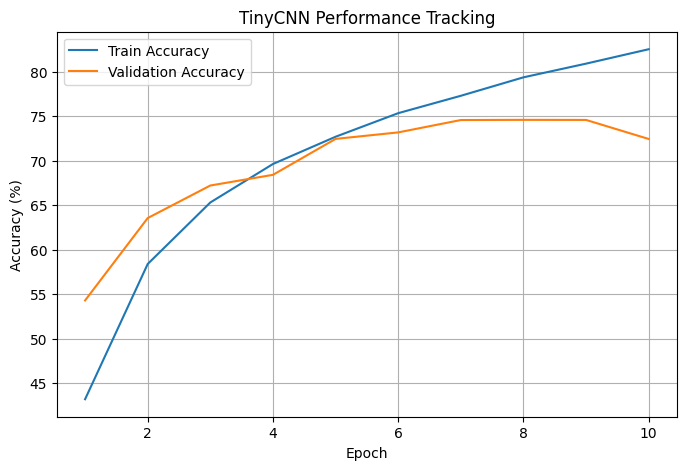

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), train_accs, label="Train Accuracy")
plt.plot(range(1, epochs + 1), val_accs, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("TinyCNN Performance Tracking")
plt.legend()
plt.grid(True)
plt.savefig("cnn_baseline_plot.png")
plt.show()

torch.save(val_accs, "cnn_val_accs.pt")

obviously there has been use of AI in making of this...

PART C :

In [14]:
import torch
import torch.nn as nn

B = 2
C = 3
H = 32
W = 32
patch_size = 4
n_embd = 128

x = torch.randn(B, C, H, W)
print("Original Image Batch Shape:", x.shape)

Original Image Batch Shape: torch.Size([2, 3, 32, 32])


In [15]:
patches = x.unfold(2, patch_size, patch_size).unfold(3, patch_size, patch_size)
patches = patches.permute(0, 2, 3, 1, 4, 5).flatten(1, 2).flatten(2)

print("Method 1 (Manual Flattened Patches) Shape:", patches.shape)

Method 1 (Manual Flattened Patches) Shape: torch.Size([2, 64, 48])


In [16]:
patch_embed = nn.Conv2d(
    in_channels=C,
    out_channels=n_embd,
    kernel_size=patch_size,
    stride=patch_size
)

x_conv = patch_embed(x).flatten(2).transpose(1, 2)

print("Method 2 (Convolution Projection) Shape:", x_conv.shape)

Method 2 (Convolution Projection) Shape: torch.Size([2, 64, 128])


In [17]:
linear_projection = nn.Linear(48, n_embd)

with torch.no_grad():
    linear_projection.weight.copy_(patch_embed.weight.flatten(1))
    linear_projection.bias.copy_(patch_embed.bias)

x_linear = linear_projection(patches)
are_identical = torch.allclose(x_conv, x_linear, atol=1e-5)

print("Do both embedding methods produce identical results?", are_identical)

Do both embedding methods produce identical results? True


In [18]:
linear_projection = nn.Linear(48, n_embd)

with torch.no_grad():
    linear_projection.weight.copy_(patch_embed.weight.flatten(1))
    linear_projection.bias.copy_(patch_embed.bias)

x_linear = linear_projection(patches)
are_identical = torch.allclose(x_conv, x_linear, atol=1e-5)

print("Do both embedding methods produce identical results?", are_identical)

Do both embedding methods produce identical results? True
